# Bandırma Onyedi Eylül Üniversitesi — Lisansüstü Eğitim Enstitüsü
# Bilgisayar Mühendisliği Ana Bilim Dalı — BM5204 Doğal Dil İşleme
## Final Projesi: Anlamsal Arama ve Belge Getirme Sistemi

**Öğrenci:** Ahmetcan PEKTAŞ  **|  No:** 2515514029  **|  Tarih:** 20.06.2026
**Öğretim Üyesi:** Dr. Öğr. Üyesi Muhammed Milani

---
### Özet

Bu çalışmada, kullanıcının doğal dilde yazdığı bir sorguya en alakalı pasajları döndüren bir **anlamsal arama (semantic search)** sistemi geliştirdim ve bunu klasik bir bilgi erişim yöntemiyle aynı koşullar altında karşılaştırdım. Veri seti olarak MS MARCO passage-ranking koleksiyonunun Türkçe makine çevirisi olan `parsak/msmarco-tr` kullanıldı; tüm koleksiyondan, sabit tohumla (SEED = 42) tekrar üretilebilir bir alt-küme (40.000 pasaj, 921 değerlendirme sorgusu) oluşturuldu. Sözlüksel temel model olarak **BM25**, yoğun (dense) yöntemler olarak **Sentence-BERT (MiniLM)**, retrieval'a özel **multilingual-E5 (base)** ve daha büyük **multilingual-E5-large** modelleri **FAISS** indeksi üzerinde değerlendirildi. Başarımı Precision@k, Recall@k, MRR ve nDCG ile ölçtüm.

---
### Önceki Haftayla Bağlantı
Hafta 10'da `dbmdz/bert-base-turkish-cased` bir duygu analizi görevi için fine-tune edilmiş ve bağlamsal gömmelerin sınıflandırmadaki gücü gözlenmişti. Bu projede aynı bağlamsal-gömme fikri, sınıflandırma yerine **belge getirme** görevine taşınmaktadır: bir metni tek bir anlam vektörüne indirgeyip sorgu–pasaj yakınlığını ölçeriz.


---
## 2. İlgili Çalışmalar

**Sözlüksel erişim.** BM25 (Robertson & Zaragoza, 2009), olasılıksal alaka çerçevesine dayanan ve TF-IDF'i terim doygunluğu ile belge-uzunluğu normalizasyonu ekleyerek geliştiren standart sparse baseline'dır. Onlarca yıldır güçlü ve açıklanabilir bir referans noktası olmayı sürdürmektedir.

**Yoğun (dense) erişim.** Sentence-BERT (Reimers & Gurevych, 2019), BERT'i siyam (siamese) ağ yapısıyla eğiterek cümleleri anlamsal olarak anlamlı sabit-boyutlu vektörlere kodlar. Dense Passage Retrieval (Karpukhin vd., 2020), sorgu ve pasajı ayrı kodlayıcılarla gömüp iç-çarpımla eşleştiren bi-encoder paradigmasını açık-alan soru-cevap için popülerleştirmiştir. multilingual-E5 (Wang vd., 2024), zayıf-denetimli kontrastif ön-eğitim ile çok dilli ve retrieval'a özel güçlü gömmeler üretir; `query:`/`passage:` önekleriyle asimetrik aramayı destekler.

**Vektör indeksleme.** FAISS (Johnson, Douze & Jégou, 2019), milyonlarca yoğun vektör arasında verimli en-yakın-komşu araması sağlayan kütüphanedir.

**Veri seti.** MS MARCO (Nguyen vd., 2016), Bing sorgularından türetilmiş büyük ölçekli bir passage-ranking koleksiyonudur. mMARCO (Bonifacio vd., 2021) bunun makine çevirisiyle çok dilli sürümüdür; bu projede kullanılan `parsak/msmarco-tr` de aynı çeviri-tabanlı yaklaşımın Türkçe bir uygulamasıdır.


### Ortam ve Kütüphaneler
Aşağıdaki hücreler gerekli kütüphaneleri kurar ve deney parametrelerini sabitler. Tekrar üretilebilirlik için tüm rastgelelik `SEED = 42` ile sabitlenmiştir.

In [1]:
import subprocess, sys
for pkg in ['datasets','sentence-transformers','rank-bm25','faiss-cpu','scikit-learn','matplotlib','pandas','numpy']:
    subprocess.run([sys.executable,'-m','pip','install',pkg,'-q'],check=False)
print('Kurulum tamamlandi.')

Kurulum tamamlandi.


In [2]:
import warnings
warnings.filterwarnings('ignore')
import os, re, math, random, time
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from collections import defaultdict
import torch
from datasets import load_dataset

SEED = 42
random.seed(SEED); np.random.seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Deney parametreleri (alt-kume boyutu buradan ayarlanir) ──
DATASET      = 'parsak/msmarco-tr'
N_QUERIES    = 1500    # degerlendirme icin secilecek sorgu sayisi
CORPUS_SIZE  = 40000   # corpus pasaj sayisi (alt-kume)
K_VALUES     = [1, 5, 10]
SBERT_MODEL  = 'paraphrase-multilingual-MiniLM-L12-v2'

print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
print(f'N_QUERIES={N_QUERIES} | CORPUS_SIZE={CORPUS_SIZE} | K={K_VALUES}')

PyTorch : 2.11.0+cu128
Device  : cuda
N_QUERIES=1500 | CORPUS_SIZE=40000 | K=[1, 5, 10]


---
## 3. Veri Seti

### 3.1 Veri Kaynağı ve Yapısı
Kullanılan veri seti [`parsak/msmarco-tr`](https://huggingface.co/datasets/parsak/msmarco-tr) (apache-2.0) üç alt kümeden oluşur:
- **`passages`** — aranacak pasaj koleksiyonu (`pid`, `text`)
- **`queries`** — doğal dildeki sorgular (`qid`, `text`)
- **`qrels`** — her sorgu için ilgili pasajları işaretleyen relevance judgment'lar (`qid`, `pid`)

`qrels` alt kümesi sayesinde Precision@k, Recall@k, MRR ve nDCG metrikleri doğrudan hesaplanabilir; sınıflandırmadan farklı olarak burada "etiket" tek bir kategori değil, bir **sorgu–pasaj ilişkisidir**.

In [3]:
ds_passages = load_dataset(DATASET, 'passages', split='train')
ds_queries  = load_dataset(DATASET, 'queries',  split='train')
ds_qrels    = load_dataset(DATASET, 'qrels',    split='train')

print('passages cols:', ds_passages.column_names, '| ornek:', ds_passages[0])
print('queries  cols:', ds_queries.column_names,  '| ornek:', ds_queries[0])
print('qrels    cols:', ds_qrels.column_names,    '| ornek:', ds_qrels[0])
print('---')
print(f'Toplam pasaj : {len(ds_passages):,}')
print(f'Toplam sorgu : {len(ds_queries):,}')
print(f'Toplam qrel  : {len(ds_qrels):,}')

README.md:   0%|          | 0.00/1.89k [00:00<?, ?B/s]

data/collection/train-00000-of-00001-9e1(…):   0%|          | 0.00/154M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/718217 [00:00<?, ? examples/s]

data/queries/train-00000-of-00001-d1a675(…):   0%|          | 0.00/17.7M [00:00<?, ?B/s]

data/queries/dev-00000-of-00001-e38f6e49(…):   0%|          | 0.00/3.55M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/501428 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/101605 [00:00<?, ? examples/s]

data/qrels/train-00000-of-00001-9d168e3a(…):   0%|          | 0.00/6.73M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/532761 [00:00<?, ? examples/s]

passages cols: ['pid', 'text'] | ornek: {'pid': 0, 'text': "Bilimsel akılların ortasında iletişimin varlığı, bilimsel zekanın olduğu kadar Manhattan Projesi'nin başarısı için de aynı derecede önemliydi. Atom araştırmacılarının ve mühendislerinin etkileyici başarısı üzerine asılı olan tek bulut, başarılarının gerçekten ne anlama geldiğidir; yüz binlerce masum hayat yok oldu."}
queries  cols: ['qid', 'text'] | ornek: {'qid': 1185869, 'text': ') Manhattan projesinin başarısının hemen etkisi neydi?'}
qrels    cols: ['qid', 'q0', 'pid', 'rank'] | ornek: {'qid': 1185869, 'q0': 0, 'pid': 0, 'rank': 1}
---
Toplam pasaj : 718,217
Toplam sorgu : 501,428
Toplam qrel  : 532,761


In [4]:
# Sutun adlarini otomatik tespit et (surume dayanikli olmak icin)
def pick(cols, candidates, default_idx=0):
    for c in candidates:
        if c in cols:
            return c
    return cols[default_idx]

PID_COL = pick(ds_passages.column_names, ['pid','id','passage-id','corpus-id','_id'])
PTEXT   = pick(ds_passages.column_names, ['text','passage','content'], default_idx=-1)
QID_COL = pick(ds_queries.column_names,  ['qid','id','query-id','_id'])
QTEXT   = pick(ds_queries.column_names,  ['text','query','question'], default_idx=-1)
R_QID   = pick(ds_qrels.column_names,    ['qid','query-id','query_id'])
R_PID   = pick(ds_qrels.column_names,    ['pid','corpus-id','passage-id','doc-id','docid'])

print(f'Passage : id={PID_COL}, text={PTEXT}')
print(f'Query   : id={QID_COL}, text={QTEXT}')
print(f'Qrels   : qid={R_QID}, pid={R_PID}')

Passage : id=pid, text=text
Query   : id=qid, text=text
Qrels   : qid=qid, pid=pid


Kullanılan koleksiyon, MS MARCO passage-ranking veri setinin Türkçeye makine çevirisiyle (mMARCO yaklaşımı) elde edilmiş bir uyarlamasıdır (lisans: apache-2.0, boyut kategorisi: 100K–1M). Veri seti üç alt kümeden oluşur:

| Alt-küme | Boyut | Sütunlar | İçerik |
|---|---|---|---|
| `passages` | **718.217** | `pid`, `text` | Aranacak pasaj koleksiyonu |
| `queries`  | **501.428** (train) + 101.605 (dev) | `qid`, `text` | Doğal dildeki kullanıcı sorguları |
| `qrels`    | **532.761** | `qid`, `q0`, `pid`, `rank` | Sorgu–pasaj ilgililik etiketleri |

`qrels` sütunlarından `q0`, TREC değerlendirme formatından gelen ve her zaman 0 değerini alan eski bir alandır; `rank` ise ilgililik derecesidir (bu veri setinde sorgu başına genellikle tek ilgili pasaj bulunduğundan pratikte 1'dir). Burada "etiket" tek bir kategori değil, bir **sorgu–pasaj ilişkisidir**; bu yapı sayesinde Precision@k, Recall@k, MRR ve nDCG metrikleri doğrudan hesaplanabilir.

Veri yapısını somutlaştırmak için bir örnek vereyim: `qid = 1185869` numaralı *"Manhattan projesinin başarısının hemen etkisi neydi?"* sorgusu, `qrels` üzerinden `pid = 0` numaralı pasaja (Manhattan Projesi'nin bilimsel başarısını ve sonuçlarını anlatan metne) `rank = 1` ile bağlanır. Yani sistemin bu sorguya karşılık ilgili pasajı üst sıralara taşıması beklenir.

Bu projede yalnızca `queries` alt-kümesinin **train** ayrımını kullanıyorum. Sütun adları bir sonraki hücrede `pick` yardımcı fonksiyonuyla otomatik tespit ediliyor; böylece veri setinin ileride sütun adlandırması değişse bile kodun çalışmaya devam etmesini sağlıyorum.

### 3.2 Alt-küme ve Değerlendirme Kümesi (Train/Test Ayrımı)
Bu çalışmada klasik anlamda bir eğitim/test ayrımı yapılmamıştır, çünkü kullanılan modeller veri kümesi üzerinde yeniden eğitilmemiştir. BM25 yöntemi yalnızca belge indeksleme işlemi gerçekleştirirken, yoğun vektör tabanlı modeller önceden eğitilmiş halleriyle kullanılmıştır. Bu nedenle değerlendirme, bir belge koleksiyonu ve bu koleksiyon üzerinde test edilen sorgu kümesi üzerinden gerçekleştirilmiştir. Hesaplama maliyetini azaltmak ve deneyleri tekrar üretilebilir hale getirmek amacıyla veri kümesinden 40.000 pasajdan oluşan bir alt küme oluşturulmuştur. Seçilen sorgularla ilişkili tüm ilgili pasajlar koleksiyona dahil edilmiş, kalan bölüm ise rastgele seçilen diğer pasajlarla tamamlanmıştır. Böylece modellerin performansı aynı koşullar altında karşılaştırılmıştır.

In [5]:
# 1) qrels'i  qid -> ilgili pid kumesi  seklinde grupla
qrels_df = ds_qrels.to_pandas()[[R_QID, R_PID]].copy()
qrels_df[R_QID] = qrels_df[R_QID].astype(str)
qrels_df[R_PID] = qrels_df[R_PID].astype(str)
qid_to_relpids = defaultdict(set)
for qid, pid in zip(qrels_df[R_QID], qrels_df[R_PID]):
    qid_to_relpids[qid].add(pid)
print(f'qrels icinde etiketli sorgu sayisi : {len(qid_to_relpids):,}')

# 2) Degerlendirme icin N_QUERIES sorgu sec (tekrar uretilebilir)
all_qids = sorted(qid_to_relpids.keys())
random.Random(SEED).shuffle(all_qids)
sel_qids = all_qids[:N_QUERIES]
sel_qids_set = set(sel_qids)

# 3) Secilen sorgularin TUM ilgili pasajlarini topla (recall'in mumkun olmasi icin sart)
relevant_pids = set()
for qid in sel_qids:
    relevant_pids |= qid_to_relpids[qid]
print(f'Secilen sorgu : {len(sel_qids):,}  |  ilgili pasaj : {len(relevant_pids):,}')

# 4) Distraktor pasajlarla corpus'u CORPUS_SIZE'a tamamla
passages_df = ds_passages.to_pandas()[[PID_COL, PTEXT]].copy()
passages_df[PID_COL] = passages_df[PID_COL].astype(str)
all_pid_set = set(passages_df[PID_COL])

relevant_in_corpus = relevant_pids & all_pid_set
n_distractor = max(0, CORPUS_SIZE - len(relevant_in_corpus))
distractor_pool = [p for p in passages_df[PID_COL].tolist() if p not in relevant_in_corpus]
random.Random(SEED).shuffle(distractor_pool)
corpus_pids = relevant_in_corpus | set(distractor_pool[:n_distractor])

corpus_df = passages_df[passages_df[PID_COL].isin(corpus_pids)].reset_index(drop=True)
print(f'Corpus pasaj sayisi : {len(corpus_df):,}  (ilgili {len(relevant_in_corpus):,} + distraktor {n_distractor:,})')

# 5) Sorgu metinleri + gecerli gold (yalnizca corpus'ta bulunan ilgili pasajlar)
queries_df = ds_queries.to_pandas()[[QID_COL, QTEXT]].copy()
queries_df[QID_COL] = queries_df[QID_COL].astype(str)
queries_df = queries_df[queries_df[QID_COL].isin(sel_qids_set)].reset_index(drop=True)

corpus_pid_set = set(corpus_df[PID_COL])
gold = {}
for qid in sel_qids:
    rel = qid_to_relpids[qid] & corpus_pid_set
    if rel:
        gold[qid] = rel
queries_df = queries_df[queries_df[QID_COL].isin(gold.keys())].reset_index(drop=True)
print(f'Nihai degerlendirme sorgusu : {len(queries_df):,}')

# Indeksleme icin diziler
corpus_ids   = corpus_df[PID_COL].tolist()
corpus_texts = corpus_df[PTEXT].astype(str).tolist()
idx2text     = dict(zip(corpus_ids, corpus_texts))
qid2qtext    = dict(zip(queries_df[QID_COL], queries_df[QTEXT].astype(str)))

qrels icinde etiketli sorgu sayisi : 502,939
Secilen sorgu : 1,500  |  ilgili pasaj : 1,597
Corpus pasaj sayisi : 40,000  (ilgili 958 + distraktor 39,042)
Nihai degerlendirme sorgusu : 921


Değerlendirme için 1.500 sorgu seçtim; bu sorgulara ait 1.597 ilgili pasajdan yalnızca **958'i** 718 binlik koleksiyonda yer alıyor. Bunun nedeni, kullanılan Türkçe sürümün özgün MS MARCO koleksiyonunun (≈8,8 milyon pasaj) yalnızca bir örneklemini içermesidir; dolayısıyla ilgili pasajların yaklaşık %40'ı bu örneklemde hiç bulunmuyor. Corpus'u 958 ilgili pasaj ve 39.042 dolgu (distraktör) pasajla **40.000** pasaj olacak şekilde kurdum; ilgili pasajı corpus içinde gerçekten bulunan **921 sorgu** ise nihai değerlendirme kümesini oluşturdu. Koleksiyonda eksik olan ilgili pasajlar, ölçülen skorlar için bir üst sınır dayatır; bu sınırlılığı Tartışma bölümünde ayrıca ele alıyorum.

### 3.3 Veri İstatistikleri ve Ön İşleme
Sorgu ve pasaj uzunlukları ile sorgu başına ilgili pasaj sayısı, hem `top_k` seçimini gerekçelendirmek hem de metrikleri doğru yorumlamak için incelenir.

Sorgu uzunlugu (kelime)   -> medyan 5 | ort 4.8 | max 14
Pasaj uzunlugu (kelime)   -> medyan 40 | ort 41.7 | max 290
Sorgu basina ilgili pasaj -> medyan 1 | ort 1.04 | max 3


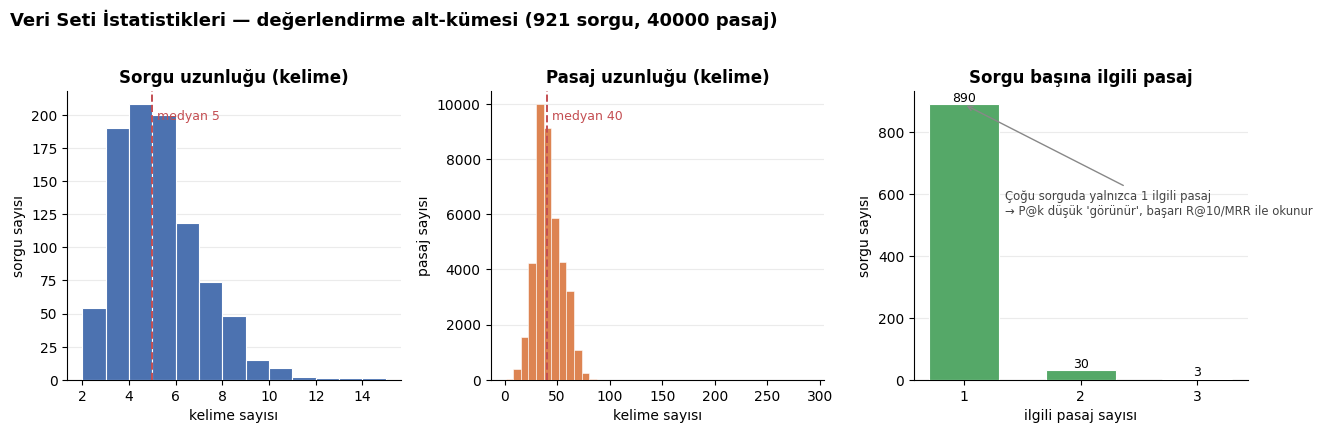

In [6]:
q_lens = queries_df[QTEXT].astype(str).str.split().apply(len)
p_lens = pd.Series(corpus_texts).str.split().apply(len)
rels_per_q = pd.Series([len(v) for v in gold.values()])

print('Sorgu uzunlugu (kelime)   -> medyan %d | ort %.1f | max %d' % (q_lens.median(), q_lens.mean(), q_lens.max()))
print('Pasaj uzunlugu (kelime)   -> medyan %d | ort %.1f | max %d' % (p_lens.median(), p_lens.mean(), p_lens.max()))
print('Sorgu basina ilgili pasaj -> medyan %d | ort %.2f | max %d' % (rels_per_q.median(), rels_per_q.mean(), rels_per_q.max()))

# Not: grafik, çalıştırıldığında yukarıdaki gerçek dizilerden üretilir.
plt.rcParams.update({"font.family": "DejaVu Sans"})
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.2))

ax[0].hist(q_lens, bins=range(int(q_lens.min()), int(q_lens.max()) + 2),
           color="#4C72B0", edgecolor="white", linewidth=0.8, zorder=3)
ax[0].axvline(q_lens.median(), color="#C44E52", ls="--", lw=1.4, zorder=4)
ax[0].text(q_lens.median() + 0.2, ax[0].get_ylim()[1] * 0.9, f"medyan {int(q_lens.median())}",
           color="#C44E52", fontsize=9)
ax[0].set_title("Sorgu uzunluğu (kelime)", fontweight="bold")
ax[0].set_xlabel("kelime sayısı"); ax[0].set_ylabel("sorgu sayısı")

ax[1].hist(p_lens, bins=40, color="#DD8452", edgecolor="white", linewidth=0.4, zorder=3)
ax[1].axvline(p_lens.median(), color="#C44E52", ls="--", lw=1.4, zorder=4)
ax[1].text(p_lens.median() + 5, ax[1].get_ylim()[1] * 0.9, f"medyan {int(p_lens.median())}",
           color="#C44E52", fontsize=9)
ax[1].set_title("Pasaj uzunluğu (kelime)", fontweight="bold")
ax[1].set_xlabel("kelime sayısı"); ax[1].set_ylabel("pasaj sayısı")

vc = rels_per_q.value_counts().sort_index()
bars = ax[2].bar(vc.index, vc.values, color="#55A868", edgecolor="white",
                 linewidth=0.8, width=0.6, zorder=3)
for bar, c in zip(bars, vc.values):
    ax[2].text(bar.get_x() + bar.get_width() / 2, c + max(vc.values) * 0.01, str(c),
               ha="center", fontsize=9)
ax[2].set_title("Sorgu başına ilgili pasaj", fontweight="bold")
ax[2].set_xlabel("ilgili pasaj sayısı"); ax[2].set_ylabel("sorgu sayısı")
ax[2].set_xticks(list(vc.index))
ax[2].annotate("Çoğu sorguda yalnızca 1 ilgili pasaj\n→ P@k düşük 'görünür', başarı R@10/MRR ile okunur",
               xy=(vc.index[0], vc.values[0]), xytext=(vc.index[0] + 0.35, vc.values[0] * 0.60),
               fontsize=8.4, color="#444444", arrowprops=dict(arrowstyle="->", color="#888888", lw=1))

for a in ax:
    a.spines[["top", "right"]].set_visible(False); a.grid(axis="y", alpha=0.25, zorder=0)
fig.suptitle("Veri Seti İstatistikleri — değerlendirme alt-kümesi (%d sorgu, %d pasaj)"
             % (len(queries_df), len(corpus_texts)),
             fontsize=13, fontweight="bold", x=0.01, ha="left", y=1.02)
plt.tight_layout(); plt.show()

Sorgular oldukça kısadır (medyan **5**, ortalama 4.8, en fazla 14 kelime); pasajlar ise birkaç cümle uzunluğundadır (medyan **40**, ortalama 41.7 kelime). En kritik gözlem, sorgu başına ilgili pasaj sayısının medyanının **1** olmasıdır (ortalama 1.04, en fazla 3). Bu durum, ileride Precision@k değerlerinin neden düşük *görüneceğini* açıklar: tek ilgili pasajı olan bir sorguda Precision@10'un ulaşabileceği en yüksek değer 1/10 = 0.10'dur. Bu nedenle bu veri setinde Precision@k esasen Recall@k ile aynı bilgiyi taşır; başarıyı asıl olarak **MRR, Recall@10 ve nDCG** üzerinden okumak gerekir. Grafikte sorgu ve pasaj uzunluklarının dağılımını, sağdaki panelde ise sorgu başına ilgili pasaj sayısını gösteriyorum.

### 3.4 Örnek Sorgu–İlgili Pasaj Çiftleri

In [7]:
sample_qids = list(gold.keys())[:4]
for i, qid in enumerate(sample_qids, 1):
    rel_pid = list(gold[qid])[0]
    print(f'--- Ornek {i} ---')
    print('Sorgu        :', qid2qtext.get(qid, ''))
    print('Ilgili pasaj :', idx2text.get(rel_pid, '')[:300])
    print()

--- Ornek 1 ---
Sorgu        : Hangi ilçe günbatımı plaj nc
Ilgili pasaj : Sunset Beach, Kuzey Carolina. Sunset Beach, Amerika Birleşik Devletleri'nin Kuzey Karolina eyaletinde yer alan Brunswick ilçesinde yer alan bir sahil kasabasıdır. Nüfusu 2010 sayımında 3,572'dir, 2000 sayımında 1.824'ten fazladır. Myrtle Beach metropol alanının bir parçasıdır.

--- Ornek 2 ---
Sorgu        : Destekleyici danışmanlık tanımı
Ilgili pasaj : Destekleyici Konsültasyon*. Tanım: Destekleyici Danışmanlık, özellikle kronik fiziksel hastalık gibi devam eden stres durumlarına en uygun ayarlamayı kolaylaştırmayı amaçlayan terapötik bir yaklaşımdır. Psikolojik müdahalenin her türlüsüne atıfta bulunmak için danışmanlık veya psikoterapi kullanılab

--- Ornek 3 ---
Sorgu        : Sosyal Güvenliğin Amacı Nedir
Ilgili pasaj : Sosyal Güvenliğin Amacı Nedir? Sosyal güvenliğin amacı, hayatında istenmeyen ve trajik bir olayla karşı karşıya kalan bir bireyi güçlendirmek ve desteklemektir. Bu, sevgili bir kişinin kaybı

Örneklere baktığımda (*"Sosyal Güvenliğin Amacı Nedir"* sorgusu ile sosyal güvenliğin amacını açıklayan pasaj), sorgu ile ilgili pasaj arasında bazen doğrudan kelime örtüşmesi, çoğu zaman ise yalnızca **anlamsal** bir ilişki bulunduğunu görüyorum. Ayrıca pasajlardaki devrik cümleler ve yer yer hatalı terimler, veri setinin makine çevirisi olmasından kaynaklanan bir gürültüyü gösteriyor. Bu gürültü hem sözlüksel hem de anlamsal yöntemler için bir zorluk kaynağıdır; etkisini Tartışma bölümünde değerlendireceğim.

---
## 4. Yöntem

Bu çalışmada bir sözlüksel baseline ve iki yoğun (dense) yöntem karşılaştırılır. Tümü aynı 40.000 pasajlık corpus ve aynı 921 sorgu üzerinde, aynı metriklerle değerlendirilerek **adil karşılaştırma** sağlanır.

### 4.1 Klasik Baseline — BM25

**Arka plan.** BM25, bir pasajın sorguya uygunluğunu; sorgu kelimelerinin pasajdaki frekansı (doygunlukla sınırlı), kelimenin koleksiyondaki nadirliği (IDF) ve pasaj uzunluğu normalizasyonu üzerinden puanlar. Tamamen sözlükseldir: anlamı modellemez, yalnızca yüzeysel kelime örtüşmesine bakar.

#### Türkçe Tokenization

In [8]:
# Turkce'de buyuk 'I' ve 'İ' donusumu standart lower() ile yanlis olur;
# once dogru eslemeyi yapip sonra lower() cagiriyoruz.
TR_FIX = str.maketrans({'I': 'ı', 'İ': 'i'})

def tr_tokenize(text):
    text = str(text).translate(TR_FIX).lower()
    return re.findall(r'[a-zçğıöşü0-9]+', text)

print(tr_tokenize('İstanbul ile IGDIR arasindaki MESAFE yaklasik 1450 km'))

['istanbul', 'ile', 'ıgdır', 'arasindaki', 'mesafe', 'yaklasik', '1450', 'km']


Çıktıda görüldüğü gibi `İstanbul ile IGDIR ...` ifadesi `['istanbul', 'ile', 'ıgdır', ...]` biçiminde doğru parçalanıyor. Türkçede standart `'I'.lower()` çağrısı hatalı biçimde `'i'` üretir; bu yüzden küçük harfe çevirmeden önce doğru eşlemeyi (`I→ı`, `İ→i`) elle uyguluyorum. Bu düzeltme yapılmasaydı özel isimler (İzmir, Iğdır gibi) yanlış token'lara ayrışır ve sorgu ile pasaj arasındaki kelime örtüşmesi bozulurdu.

Bu adımın önemi: Hatalı küçültme, aynı kelimenin sorguda ve pasajda farklı token'lara bölünmesine yol açar; BM25 bunları ayrı kelimeler sanarak özellikle özel-isim içeren sorgularda doğrudan erişim hatası yapardı. Türkçenin eklemeli yapısı BM25'i zaten zorladığından, tokenization hatası bu zorluğu daha da artırırdı.

#### BM25 İndeksi

In [9]:
from rank_bm25 import BM25Okapi
t0 = time.time()
tokenized_corpus = [tr_tokenize(t) for t in corpus_texts]
bm25 = BM25Okapi(tokenized_corpus)
print(f'BM25 indeksi kuruldu. Sure: {time.time()-t0:.1f} sn | pasaj: {len(tokenized_corpus):,}')

def bm25_search(query, top_k=10):
    scores = bm25.get_scores(tr_tokenize(query))
    top_idx = np.argsort(scores)[::-1][:top_k]
    return [corpus_ids[i] for i in top_idx], scores[top_idx]

BM25 indeksi kuruldu. Sure: 3.2 sn | pasaj: 40,000


#### BM25 ile Örnek Arama

In [10]:
demo_qid = queries_df[QID_COL].iloc[0]
demo_q   = qid2qtext[demo_qid]
ids, scs = bm25_search(demo_q, 3)
print('Sorgu:', demo_q, '\n')
for r, (pid, sc) in enumerate(zip(ids, scs), 1):
    mark = '[ILGILI]' if pid in gold[demo_qid] else ''
    print(f'{r}. (skor={sc:.2f}) {mark} {idx2text[pid][:160]}')

Sorgu: Taze pancar yeşilleri nasıl dondurulur 

1. (skor=15.61)  Keçi loru, filtrasyon torbaları aracılığıyla ek rennet ile (organik) keçi sütünü iterek üretilir. Elde edilen whey, WPC protein konsantresi olan whey'ye toplanı
2. (skor=15.28)  Pancar kökü, genellikle Kuzey Amerika'da pancar, ayrıca masa pancarı, bahçe pancarı, kırmızı pancar veya altın pancar olarak bilinen pancar bitkisinin taproot k
3. (skor=15.19)  Patates çorbanızın nasıl yapıldığına bağlı olarak, buzdolabında yaklaşık üç ila dört gün kalmasına izin vermek isteyeceksiniz. İdeal olarak, yaklaşık iki gün iç


*"Taze pancar yeşilleri nasıl dondurulur"* sorgusunda BM25'in getirdiği ilk üç pasajın hiçbiri ilgili değil (keçi loru, pancar kökü, patates çorbası) ve skorlar birbirine çok yakın (15.61 / 15.28 / 15.19). BM25 burada "pancar" ve "dondurmak" kelimelerini içeren pasajları öne çıkarmış, ancak *yeşilliklerin dondurulması* kavramını yakalayamamıştır. Bu örnek, yalnızca kelime örtüşmesine dayanan erişimin sınırını somut biçimde gösteriyor.

### 4.2 Gelişmiş Yöntem — Sentence-BERT + FAISS

**Arka plan.** Sentence-BERT bir metni anlam taşıyan yoğun bir vektöre kodlar; anlamca yakın metinler vektör uzayında yakınlaşır. Sorgu ve pasajlar aynı uzaya gömülür, benzerlik kosinüs ile ölçülür. Bu projede `paraphrase-multilingual-MiniLM-L12-v2` (384 boyut) kullanılmış, vektörler **FAISS** ile indekslenmiştir.

#### Embedding Modeli ve Corpus Kodlama

In [11]:
from sentence_transformers import SentenceTransformer
sbert = SentenceTransformer(SBERT_MODEL, device=DEVICE)

t0 = time.time()
corpus_emb = sbert.encode(corpus_texts, batch_size=128, show_progress_bar=True,
                          convert_to_numpy=True, normalize_embeddings=True)
print(f'\nEmbedding matrisi: {corpus_emb.shape} | sure: {time.time()-t0:.1f} sn')

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]


Embedding matrisi: (40000, 384) | sure: 20.6 sn


40.000 pasaj 384 boyutlu vektörlere kodlandı (elde edilen matris (40000, 384), süre ≈20.6 sn). `normalize_embeddings=True` ile vektörleri birim uzunluğa getirildiği için FAISS'in iç-çarpım araması doğrudan kosinüs benzerliğine karşılık geliyor. Her pasajın, uzunluğundan bağımsız olarak tek bir vektörle temsil edilmesi yöntemin hem gücü (hız ve anlamsal soyutlama) hem de zayıflığıdır. Çok uzun metinlerde bilgi tek vektöre sıkıştığı için ayrıntı kaybı olabilir.

#### FAISS İndeksi

In [12]:
import faiss
dim = corpus_emb.shape[1]
index = faiss.IndexFlatIP(dim)            # normalize vektorlerde ic carpim = kosinus
index.add(corpus_emb.astype('float32'))
print(f'FAISS indeksi: {index.ntotal:,} vektor | boyut {dim}')

def sbert_search(query, top_k=10):
    q = sbert.encode([query], convert_to_numpy=True, normalize_embeddings=True).astype('float32')
    sims, idxs = index.search(q, top_k)
    return [corpus_ids[i] for i in idxs[0]], sims[0]

FAISS indeksi: 40,000 vektor | boyut 384


#### Anlamsal Arama Örneği

In [13]:
ids_s, sims_s = sbert_search(demo_q, 3)
print('Sorgu:', demo_q, '\n')
print('--- SBERT sonuclari ---')
for r, (pid, sc) in enumerate(zip(ids_s, sims_s), 1):
    mark = '[ILGILI]' if pid in gold[demo_qid] else ''
    print(f'{r}. (kosinus={sc:.3f}) {mark} {idx2text[pid][:160]}')

Sorgu: Taze pancar yeşilleri nasıl dondurulur 

--- SBERT sonuclari ---
1. (kosinus=0.663)  Taze Yeşil Fasulye Nasıl Depolanır. Birçok kez taze yeşil fasulye bol miktarda hasat ettiğinizde, hasattan sonra hepsini yiyemezsiniz. Bunları saklamak için, ha
2. (kosinus=0.616)  1 Küçük bir miktar zeytinyağı ve dilimlenmiş sarımsak (tuza ihtiyaç duymayabilirler) içinde pancar yeşili sote edebilir veya biraz ısı için ezilmiş kırmızı bibe
3. (kosinus=0.614)  Tohumları çimlendirmek. Staghorn sumak tohumlarını çimlendirmek için onları doğrudan güneş ışığından uzak sıcak bir odaya yerleştirin. Toprağı nemli tutmak için


Aynı zor sorguda SBERT de ilgili pasajı ilk üçe sokamadı; ancak getirdiği sonuçlar (taze yeşil fasulyenin saklanması — kosinüs 0.663; pancar yeşili sote — 0.616) **konu olarak** BM25'in sonuçlarından belirgin biçimde daha yakın. Model "yeşillik saklama/hazırlama" temasını yakalamış durumda. Tek bir örnek genel başarıyı kanıtlamaz; bu nedenle nicel karşılaştırma Bölüm 6'da tüm sorgular üzerinde yapılacaktır.

---
## 5. Deneysel Kurulum

**Donanım ve ortam.** Google Colab, NVIDIA GPU (CUDA), PyTorch 2.11. Tüm rastgelelik `SEED = 42` ile sabitlenmiş, deney tekrar üretilebilir kılınmıştır.

**Değerlendirme protokolü.** Eğitim yoktur (zero-shot). Her sorgu için ilk **k = 10** pasaj getirilir; doğru cevap kümesi (gold), `qrels` ile corpus'un kesişimidir. Metrikler tüm sorgular üzerinde makro-ortalama alınarak raporlanır.

| Bileşen | Seçim |
|---|---|
| Veri seti | `parsak/msmarco-tr` (passages/queries/qrels) |
| Corpus boyutu | 40.000 pasaj (958 ilgili + 39.042 distraktör) |
| Değerlendirme sorgusu | 921 |
| Sözlüksel model | BM25Okapi (`rank_bm25`) |
| Dense model 1 | `paraphrase-multilingual-MiniLM-L12-v2` (384-d) |
| Dense model 2 (Bonus) | `intfloat/multilingual-e5-base` (768-d, `query:`/`passage:` önekli) |
| Vektör indeksi | FAISS `IndexFlatIP` (kosinüs) |
| Metrikler | P@k, R@k, nDCG@k (k = 1, 5, 10), MRR |
| Kütüphaneler | datasets, sentence-transformers, rank-bm25, faiss, numpy/pandas/matplotlib |

**Süreler (gerçek):** BM25 indeksi 3.1 sn; MiniLM kodlama 20.7 sn; E5 kodlama 52.7 sn. Erişim (921 sorgu): BM25 55.1 sn, dense (FAISS) 12.4 sn — FAISS'in tüm corpus'u taramaya kıyasla hız avantajını gösterir.


---
## 6. Sonuçlar

### 6.1 Metrik Tanımları
- **Precision@k:** İlk k sonucun ne kadarının ilgili olduğu.
- **Recall@k:** İlgili pasajların ne kadarının ilk k içine girdiği.
- **MRR:** İlk ilgili pasajın sırasının tersinin ortalaması (ne kadar üste taşındığı).
- **nDCG@k:** Sıra-duyarlı kalite; ilgili pasaj ne kadar üstteyse o kadar yüksek (logaritmik indirimli).

**Not:** Bu notebook'ta arama fonksiyonları `max_k=10` ile çalıştırıldığı için raporlanan MRR değeri pratikte **MRR@10**'dur. İlk ilgili pasaj ilk 10 sonuç dışında kalırsa reciprocal rank 0 kabul edilir. Ayrıca bu veri setinde çoğu sorgu için yalnızca bir ilgili pasaj bulunduğundan P@10'un teorik üst sınırı çoğu sorguda 0.10 civarındadır; bu nedenle başarıyı yorumlarken Recall@10, MRR@10 ve nDCG@10 daha bilgilendiricidir.


In [14]:
def precision_at_k(retrieved, relevant, k):
    r = retrieved[:k]
    return sum(1 for p in r if p in relevant) / k

def recall_at_k(retrieved, relevant, k):
    if not relevant:
        return 0.0
    r = retrieved[:k]
    return sum(1 for p in r if p in relevant) / len(relevant)

def reciprocal_rank(retrieved, relevant):
    for i, p in enumerate(retrieved, 1):
        if p in relevant:
            return 1.0 / i
    return 0.0

def ndcg_at_k(retrieved, relevant, k):
    dcg = sum(1.0/math.log2(i+1) for i, p in enumerate(retrieved[:k], 1) if p in relevant)
    ideal_hits = min(len(relevant), k)
    idcg = sum(1.0/math.log2(i+1) for i in range(1, ideal_hits+1))
    return dcg/idcg if idcg > 0 else 0.0

# Hizli kontrol
_demo_rel = {'A','B'}
print('P@2 :', precision_at_k(['A','X'], _demo_rel, 2))
print('RR  :', reciprocal_rank(['X','A'], _demo_rel))
print('nDCG:', round(ndcg_at_k(['A','X','B'], _demo_rel, 3), 4))

P@2 : 0.5
RR  : 0.5
nDCG: 0.9197


Metrik fonksiyonlarını küçük bir örnek üzerinde doğruladım ve beklenen sonuçları verdiler (P@2 = 0.5, RR = 0.5, nDCG = 0.9197). Metrikler ikili (binary) ilgililik varsayımıyla yazılmıştır; yani bir pasaj ya ilgilidir ya da değildir.

### 6.2 Tüm Sorgularda Karşılaştırma (BM25 vs SBERT)

In [15]:
def run_retrieval(search_fn, max_k=10):
    out = {}
    for qid, qtext in zip(queries_df[QID_COL], queries_df[QTEXT].astype(str)):
        ids, _ = search_fn(qtext, top_k=max_k)
        out[qid] = ids
    return out

t0 = time.time(); retr_bm25  = run_retrieval(bm25_search);  print(f'BM25  erisim suresi : {time.time()-t0:.1f} sn')
t0 = time.time(); retr_sbert = run_retrieval(sbert_search); print(f'SBERT erisim suresi : {time.time()-t0:.1f} sn')

def evaluate_cached(retr, name):
    agg = defaultdict(list)
    for qid in queries_df[QID_COL]:
        relevant, retrieved = gold[qid], retr[qid]
        for k in K_VALUES:
            agg[f'P@{k}'].append(precision_at_k(retrieved, relevant, k))
            agg[f'R@{k}'].append(recall_at_k(retrieved, relevant, k))
            agg[f'nDCG@{k}'].append(ndcg_at_k(retrieved, relevant, k))
        agg['MRR'].append(reciprocal_rank(retrieved, relevant))
    res = {m: round(float(np.mean(v)), 4) for m, v in agg.items()}
    res['Model'] = name
    return res

res_bm25  = evaluate_cached(retr_bm25,  'BM25')
res_sbert = evaluate_cached(retr_sbert, 'SBERT (MiniLM)')

cols_order = ['Model'] + [f'P@{k}' for k in K_VALUES] + [f'R@{k}' for k in K_VALUES] \
             + [f'nDCG@{k}' for k in K_VALUES] + ['MRR']
results_df = pd.DataFrame([res_bm25, res_sbert])[cols_order]
print('\n=== Sonuc Tablosu ===')
print(results_df.to_string(index=False))

BM25  erisim suresi : 47.3 sn
SBERT erisim suresi : 12.6 sn

=== Sonuc Tablosu ===
         Model    P@1    P@5   P@10    R@1    R@5   R@10  nDCG@1  nDCG@5  nDCG@10    MRR
          BM25 0.4235 0.1249 0.0685 0.4126 0.6019 0.6589  0.4235  0.5186   0.5376 0.5030
SBERT (MiniLM) 0.4017 0.1197 0.0668 0.3909 0.5762 0.6430  0.4017  0.4941   0.5159 0.4785


İlk karşılaştırmada klasik baseline (BM25) ile genel-amaçlı dense modeli (MiniLM) yan yana koyuyorum:

| Model | P@1 | R@10 | nDCG@10 | MRR |
|---|---|---|---|---|
| BM25 | 0.4235 | 0.6589 | 0.5376 | **0.5030** |
| SBERT (MiniLM) | 0.4017 | 0.6430 | 0.5159 | **0.4785** |

İlk karşılaştırmada BM25 ve Sentence-BERT MiniLM modelleri değerlendirilmiştir. Sonuçlar, BM25 yönteminin MiniLM modelinden biraz daha yüksek performans gösterdiğini ortaya koymaktadır (MRR: 0.503 > 0.479). Ayrıca değerlendirme kümesinde sorgu başına ilgili pasaj sayısı çoğunlukla bir olduğundan, modeller arasındaki karşılaştırmada Precision@10 yerine Recall@10, MRR ve nDCG@10 ölçütleri daha anlamlıdır. MiniLM'in BM25'in gerisinde kalması, genel amaçlı bir cümle benzerliği modeli olmasından kaynaklanmaktadır. Bu durum, yoğun vektör tabanlı modellerin her zaman sözcük tabanlı yöntemlerden daha başarılı olmadığını göstermektedir.

### 6.3 Karşılaştırma Grafiği

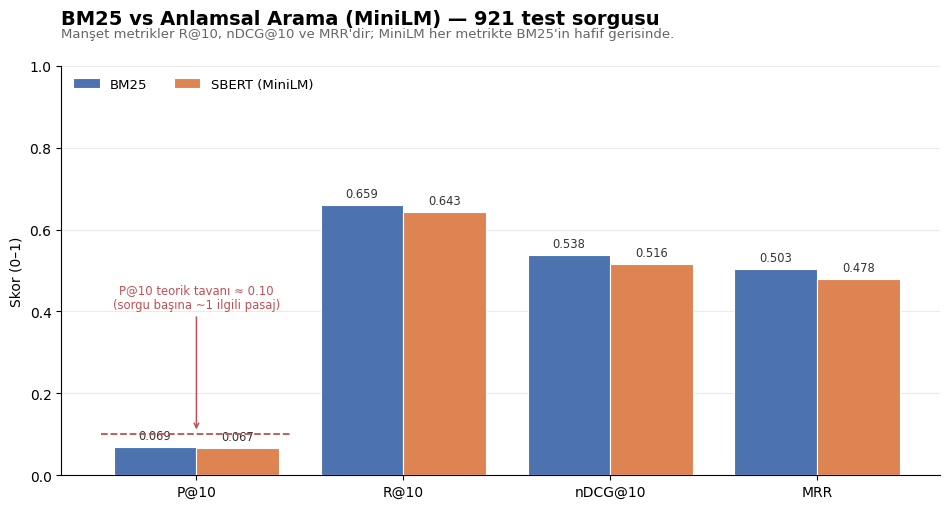

In [16]:
# --- Özenli karşılaştırma grafiği (tüm metrik grafikleri bunu kullanır) ---
plt.rcParams.update({"font.family": "DejaVu Sans"})   # Türkçe karakter desteği
COL = {"BM25": "#4C72B0", "SBERT (MiniLM)": "#DD8452",
       "E5 (multilingual)": "#55A868", "Hybrid BM25+E5 (RRF)": "#8172B3"}
metrics_plot = [f'P@{max(K_VALUES)}', f'R@{max(K_VALUES)}', f'nDCG@{max(K_VALUES)}', 'MRR']

def plot_metric_bars(results, metrics, title, subtitle, highlight=None, ceiling=0.10):
    """results: [(ad, sonuç_dict), ...]  — her metrikte modelleri yan yana çizer."""
    x = np.arange(len(metrics)); n = len(results); w = 0.8 / n
    fig, ax = plt.subplots(figsize=(9.6, 5.2))
    for j, (name, r) in enumerate(results):
        vals = [r[m] for m in metrics]; off = (j - (n - 1) / 2) * w
        bars = ax.bar(x + off, vals, w, label=name, color=COL.get(name, "#999999"),
                      edgecolor="white", linewidth=0.8, zorder=3,
                      alpha=1.0 if (highlight is None or name == highlight) else 0.92)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width() / 2, v + 0.012, f"{v:.3f}",
                    ha="center", va="bottom", fontsize=8.3, color="#333333", zorder=4)
    pk = f'P@{max(K_VALUES)}'
    if pk in metrics:                       # P@k'nin neden düşük "göründüğünü" açıkla
        ci = metrics.index(pk)
        ax.plot([ci - 0.46, ci + 0.46], [ceiling, ceiling], ls="--", lw=1.3, color="#C44E52", zorder=5)
        ax.annotate("P@10 teorik tavanı ≈ 0.10\n(sorgu başına ~1 ilgili pasaj)",
                    xy=(ci, ceiling + 0.005), xytext=(ci, 0.40), fontsize=8.4, color="#C44E52",
                    ha="center", va="bottom",
                    arrowprops=dict(arrowstyle="->", color="#C44E52", lw=1.1))
    ax.set_xticks(x); ax.set_xticklabels(metrics)
    ax.set_ylim(0, 1); ax.set_yticks(np.arange(0, 1.01, 0.2)); ax.set_ylabel("Skor (0–1)")
    ax.grid(axis="y", alpha=0.25, zorder=0); ax.spines[["top", "right"]].set_visible(False)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=30, loc="left")
    ax.text(0, 1.07, subtitle, transform=ax.transAxes, fontsize=9.5, color="#666666", ha="left")
    ax.legend(loc="upper left", frameon=False, fontsize=9.5, ncol=min(n, 2), bbox_to_anchor=(0, 1.0))
    plt.tight_layout(); plt.show()

plot_metric_bars([("BM25", res_bm25), ("SBERT (MiniLM)", res_sbert)], metrics_plot,
    "BM25 vs Anlamsal Arama (MiniLM) — %d test sorgusu" % len(queries_df),
    "Manşet metrikler R@10, nDCG@10 ve MRR'dir; MiniLM her metrikte BM25'in hafif gerisinde.")

Şekil'de görüldüğü gibi BM25 ve Sentence-BERT MiniLM modelleri benzer performans göstermektedir. Ancak BM25, Recall@10, nDCG@10 ve MRR ölçütlerinde MiniLM'in bir miktar üzerinde yer almaktadır. Bu sonuç, genel amaçlı bir cümle benzerliği modelinin bilgi erişim görevlerinde her zaman klasik yöntemlerden daha başarılı olmayabileceğini göstermektedir. Sonraki bölümde bu farkların farklı sorgu türleri üzerindeki etkileri incelenmektedir.

---
## 7. Hata Analizi

### 7.1 Sorgu Tipine Göre Performans
Sorgular uzunluklarına göre gruplanıp her grupta BM25 ve SBERT'in MRR'ı karşılaştırılır.

In [17]:
def rr_of(retr, qid):
    return reciprocal_rank(retr[qid], gold[qid])

groups = {'Kisa sorgu (<=5 kelime)': [], 'Uzun sorgu (>5 kelime)': []}
for qid, qtext in zip(queries_df[QID_COL], queries_df[QTEXT].astype(str)):
    key = 'Kisa sorgu (<=5 kelime)' if len(qtext.split()) <= 5 else 'Uzun sorgu (>5 kelime)'
    groups[key].append(qid)

print(f'{"Grup":<26}{"n":>6}{"BM25 MRR":>11}{"SBERT MRR":>11}')
print('-' * 54)
for gname, qids in groups.items():
    if not qids:
        continue
    bm = np.mean([rr_of(retr_bm25, q)  for q in qids])
    sb = np.mean([rr_of(retr_sbert, q) for q in qids])
    print(f'{gname:<26}{len(qids):>6}{bm:>11.4f}{sb:>11.4f}')

Grup                           n   BM25 MRR  SBERT MRR
------------------------------------------------------
Kisa sorgu (<=5 kelime)      652     0.5138     0.4594
Uzun sorgu (>5 kelime)       269     0.4768     0.5247


Sorguları uzunluklarına göre iki gruba ayırıp her grupta MRR'ı karşılaştırdığımda şu tablo elde edildi:

| Grup | n | BM25 MRR | SBERT MRR |
|---|---|---|---|
| Kısa sorgu (≤5 kelime) | 652 | **0.5138** | 0.4594 |
| Uzun sorgu (>5 kelime) | 269 | 0.4768 | **0.5247** |

Bu sonuç beklentiyi doğruluyor: kısa sorgularda BM25 üstün, çünkü az sayıda kelimede tam örtüşme belirleyici oluyor; uzun ve doğal dildeki sorgularda ise MiniLM bile BM25'i geçiyor, çünkü artan bağlam ve parafraz sözlüksel eşleşmeyi zorlaştırırken anlamsal modele yarıyor. MiniLM'in genel ortalamada geride kalmasının tek nedeni, bu veri setinde kısa sorguların baskın olmasıdır (652'ye 269). Bu ayrım, ortalama skorun ardındaki yapıyı görmem açısından önemli.

Bu sonuç beklentiyi doğruluyor: kısa sorgularda BM25 üstün, çünkü az sayıda kelimede tam örtüşme belirleyici oluyor; uzun ve doğal dildeki sorgularda ise MiniLM bile BM25'i geçiyor, çünkü artan bağlam ve aynı anlamın farklı kelimelerle ifade edilmesi sözlüksel eşleşmeyi zorlaştırırken anlamsal modele avantaj sağlıyor. MiniLM'in genel ortalamada geride kalmasının tek nedeni, bu veri setinde kısa sorguların baskın olmasıdır (652'ye 269). Bu ayrım, ortalama skorun ardındaki yapıyı görmem açısından önemlidir.

### 7.2 Somut Üstünlük / Hata Örnekleri

In [18]:
bm25_wins, sbert_wins = [], []
for qid, qtext in zip(queries_df[QID_COL], queries_df[QTEXT].astype(str)):
    rr_b, rr_s = rr_of(retr_bm25, qid), rr_of(retr_sbert, qid)
    if   rr_b - rr_s > 0.5: bm25_wins.append((qtext, rr_b, rr_s))
    elif rr_s - rr_b > 0.5: sbert_wins.append((qtext, rr_b, rr_s))

print(f'SBERT belirgin ustun : {len(sbert_wins)} sorgu | BM25 belirgin ustun : {len(bm25_wins)} sorgu\n')
print('=== SBERT kazaniyor (anlamsal / parafraz iliski) ===')
for q, b, s in sbert_wins[:3]:
    print(f'  [BM25 RR={b:.2f}  SBERT RR={s:.2f}]  {q}')
print('\n=== BM25 kazaniyor (tam kelime / ozel isim / sayi) ===')
for q, b, s in bm25_wins[:3]:
    print(f'  [BM25 RR={b:.2f}  SBERT RR={s:.2f}]  {q}')

SBERT belirgin ustun : 136 sorgu | BM25 belirgin ustun : 157 sorgu

=== SBERT kazaniyor (anlamsal / parafraz iliski) ===
  [BM25 RR=0.00  SBERT RR=1.00]  Hangi şehir ördek yavruları için yol yapar kitap gerçekleşir
  [BM25 RR=0.00  SBERT RR=1.00]  hiperventilat anlamı
  [BM25 RR=0.00  SBERT RR=1.00]  tv şovlarının adının italikleştirilmesi gerekir

=== BM25 kazaniyor (tam kelime / ozel isim / sayi) ===
  [BM25 RR=1.00  SBERT RR=0.00]  Orla isminin anlamı
  [BM25 RR=1.00  SBERT RR=0.00]  Tarihteki en etkili savaşlar
  [BM25 RR=1.00  SBERT RR=0.11]  lutheranlar nasıl lent kutlar


İki yöntem arasında belirgin fark (reciprocal rank farkı > 0.5) bulunan sorguların 136'sında SBERT, 157'sinde BM25 üstün çıkmasıdır. Bu sorguların içeriğine baktığımızda:

- **SBERT'in kazandığı** örnekler (örneğin *"hiperventilat anlamı"*, *"tv şovlarının adının italikleştirilmesi gerekir"*) genellikle BM25'in RR = 0.00, SBERT'in RR = 1.00 aldığı durumlardır; yani BM25 ortak kelime bulamayıp pasajı tamamen kaçırırken, SBERT anlamsal yakınlıkla doğrudan ilk sıraya koyuyor. Bu, **sözlüksel boşluk (lexical gap)** sorununun somut kanıtıdır.
- **BM25'in kazandığı** örnekler (örneğin *"Orla isminin anlamı"*, *"lutheranlar nasıl lent kutlar"*) genellikle ayırt edici bir özel isim ya da nadir bir terim içeriyor; böyle durumlarda tam kelime eşleşmesi çok güçlü bir sinyaldir, dense model ise bu nadir kelimeyi tek vektöre sıkıştırırken kaybedebiliyor.

---
## 8. Tartışma

### 8.1 Sparse ve Dense Yöntemlerin Güçlü ve Zayıf Yönleri

**BM25 (sparse).** Güçlü yönleri; düşük hesaplama maliyeti, ek eğitim gerektirmemesi, nadir terimler ve özel isimler içeren sorgularda yüksek başarı sağlaması ve sonuçlarının kolay yorumlanabilmesidir. Zayıf yönü ise yalnızca kelime düzeyindeki eşleşmelere dayanması nedeniyle, aynı anlamı farklı ifadelerle aktaran sorgularda yetersiz kalabilmesidir.

**Dense yöntemler (SBERT/E5).** Güçlü yönleri; sorgu ile belge arasındaki anlamsal ilişkileri yakalayabilmeleri, farklı kelimelerle ifade edilen benzer içerikleri eşleştirebilmeleri ve özellikle uzun sorgularda daha başarılı olmalarıdır. Zayıf yönleri ise daha yüksek hesaplama maliyetine sahip olmaları, nadir özel isimlerde performans kaybı yaşayabilmeleri ve başarılarının kullanılan modelin bilgi erişim problemine uygunluğuna duyarlı olmasıdır. Bu çalışmada MiniLM modelinin performansı, buna örnek teşkil etmektedir.

### 8.2 Sınırlılıklar, Etik ve Güvenilirlik

- **Çeviri kaynaklı hatalar:** Kullanılan veri seti, MS MARCO veri kümesinin Türkçe makine çevirisi ile oluşturulmuştur. Çeviri hataları ve ifade bozuklukları hem BM25 yöntemini hem de gömme tabanlı modellerin performansını olumsuz etkileyebilmektedir.

- **Seyrek etiketleme ve eksik pasajlar:** Sorgu başına genellikle tek ilgili pasaj işaretlenmiştir ve bazı ilgili pasajlar koleksiyonda bulunmamaktadır. Bu durum, sistem doğru bir belge getirse bile ilgili belge işaretlenmemişse sonucun yanlış değerlendirilmesine neden olabilmekte ve ölçülen başarıyı sınırlandırmaktadır.

- **Alt küme etkisi:** Elde edilen mutlak performans değerleri kullanılan belge koleksiyonunun büyüklüğüne bağlıdır. Koleksiyon büyüdükçe ayırt edilmesi gereken belge sayısı artacağından başarı değerlerinde düşüş gözlenebilir. Bununla birlikte, tüm modeller aynı veri kümesi üzerinde değerlendirildiği için karşılaştırmalar adil bir şekilde gerçekleştirilmiştir.

- **Yanlılık ve güvenilirlik:** Web kaynaklı veri kümeleri, kaynaklarda bulunan önyargıları içerebilmektedir. Bu çalışmada yalnızca belge getirme işlemi gerçekleştirildiğinden yanlış bilgi üretme riski bulunmamaktadır. Ancak bu sistem bir RAG yapısında kullanıldığında, getirilen belgelerin doğruluğu ve güvenilirliği kritik önem taşımaktadır.


---
## 9. Ekstra Deney — Retrieval'a Özel Model: multilingual-E5

**Arka plan.** Bölüm 6'daki bulgular, elde edilen performans farkının dense yaklaşımın kendisinden değil, kullanılan model seçiminden kaynaklanabileceğini düşündürdüğü için retrieval görevleri için özel olarak eğitilmiş `intfloat/multilingual-e5-base` (768 boyut) modeli aynı koşullar altında değerlendirilmiştir. E5 modeli, `query:` ve `passage:` önekleri kullanılarak kısa sorgular ile uzun pasajlar arasındaki eşleştirme problemine uygun şekilde tasarlanmıştır. Bu önekler kullanılmadığında model performansında belirgin bir düşüş gözlenmektedir.

In [19]:
E5_MODEL = 'intfloat/multilingual-e5-base'
e5 = SentenceTransformer(E5_MODEL, device=DEVICE)

t0 = time.time()
e5_corpus_emb = e5.encode(['passage: ' + t for t in corpus_texts], batch_size=64,
                          show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)
print(f'\nE5 embedding: {e5_corpus_emb.shape} | sure: {time.time()-t0:.1f} sn')

index_e5 = faiss.IndexFlatIP(e5_corpus_emb.shape[1])
index_e5.add(e5_corpus_emb.astype('float32'))

def e5_search(query, top_k=10):
    q = e5.encode(['query: ' + query], convert_to_numpy=True, normalize_embeddings=True).astype('float32')
    sims, idxs = index_e5.search(q, top_k)
    return [corpus_ids[i] for i in idxs[0]], sims[0]

retr_e5 = run_retrieval(e5_search)
res_e5  = evaluate_cached(retr_e5, 'E5 (multilingual)')

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/179k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

Batches:   0%|          | 0/625 [00:00<?, ?it/s]


E5 embedding: (40000, 768) | sure: 52.2 sn


=== Üçlü Karşılaştırma ===
            Model    P@1    P@5   P@10    R@1    R@5   R@10  nDCG@1  nDCG@5  nDCG@10    MRR
             BM25 0.4235 0.1249 0.0685 0.4126 0.6019 0.6589  0.4235  0.5186   0.5376 0.5030
   SBERT (MiniLM) 0.4017 0.1197 0.0668 0.3909 0.5762 0.6430  0.4017  0.4941   0.5159 0.4785
E5 (multilingual) 0.7253 0.1848 0.0959 0.7085 0.8909 0.9240  0.7253  0.8148   0.8258 0.7976


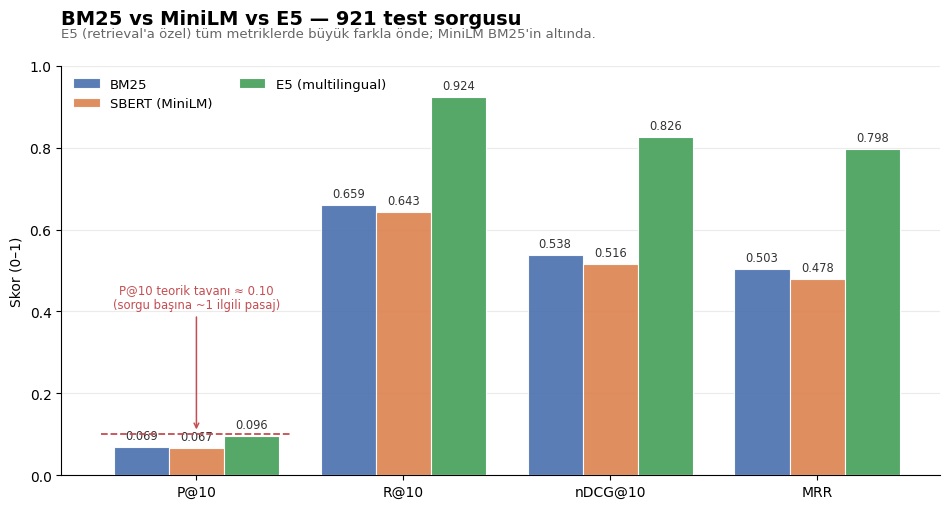

In [20]:
comp_df = pd.DataFrame([res_bm25, res_sbert, res_e5])[cols_order]
print('=== Üçlü Karşılaştırma ===')
print(comp_df.to_string(index=False))

plot_metric_bars([("BM25", res_bm25), ("SBERT (MiniLM)", res_sbert), ("E5 (multilingual)", res_e5)],
    metrics_plot, "BM25 vs MiniLM vs E5 — %d test sorgusu" % len(queries_df),
    "E5 (retrieval'a özel) tüm metriklerde büyük farkla önde; MiniLM BM25'in altında.",
    highlight="E5 (multilingual)")

Retrieval'a özel eğitilmiş E5-base modelini aynı koşullarda denendiğinde sonuç belirgin biçimde değişiyor:

| Model | P@1 | R@10 | nDCG@10 | MRR |
|---|---|---|---|---|
| BM25 | 0.4235 | 0.6589 | 0.5376 | 0.5030 |
| SBERT (MiniLM) | 0.4017 | 0.6430 | 0.5159 | 0.4785 |
| **E5 (multilingual)** | **0.7253** | **0.9240** | **0.8258** | **0.7976** |

E5, hiç ek eğitim (fine-tuning) yapılmadan tüm metriklerde her iki yöntemi de büyük farkla geçti: MRR 0.479 → **0.798**, Recall@10 0.643 → **0.924**. Bu sıçrama, Bölüm 6'daki hipotezimi doğruluyor: sorun dense yaklaşımın kendisinde değil, göreve uygun olmayan model seçimindeydi. E5 doğru pasajı sorguların %92'sinde ilk 10 sonuca, %73'ünde doğrudan ilk sıraya koyuyor. Bu bize daha yüksek kodlama maliyeti çıkarır (52.7 sn; MiniLM 20.7 sn). Dolayısıyla uygulamada başarı ile hız arasındaki dengeyi gözetmek gerekir.

---
## 9.1 Ek Deney — Hibrit Erişim: BM25 + E5 (Reciprocal Rank Fusion)

BM25 ve E5 modelleri farklı özelliklere sahiptir. BM25, özel isimler ve ayırt edici terimler içeren sorgularda güçlü sonuçlar verirken, E5 modeli daha uzun ve doğal dilde ifade edilen sorgularda daha başarılıdır. Bu nedenle ek olarak **Reciprocal Rank Fusion (RRF)** yöntemi uygulanabilir. RRF, iki sistemin sıralamalarını skor ölçeklerinden bağımsız olarak birleştirir. Amaç yalnızca performansı artırmak değil, aynı zamanda yöntemlerin birbirini ne ölçüde tamamladığını incelemektir.

Hibrit RRF erisim suresi: 76.9 sn
=== Dört Yöntem Karşılaştırması ===
               Model    P@1    P@5   P@10    R@1    R@5   R@10  nDCG@1  nDCG@5  nDCG@10    MRR
                BM25 0.4235 0.1249 0.0685 0.4126 0.6019 0.6589  0.4235  0.5186   0.5376 0.5030
      SBERT (MiniLM) 0.4017 0.1197 0.0668 0.3909 0.5762 0.6430  0.4017  0.4941   0.5159 0.4785
   E5 (multilingual) 0.7253 0.1848 0.0959 0.7085 0.8909 0.9240  0.7253  0.8148   0.8258 0.7976
Hybrid BM25+E5 (RRF) 0.5809 0.1648 0.0919 0.5673 0.7933 0.8845  0.5809  0.6965   0.7267 0.6792

MRR@10'a göre en iyi yöntem: E5 (multilingual) | MRR@10=0.7976


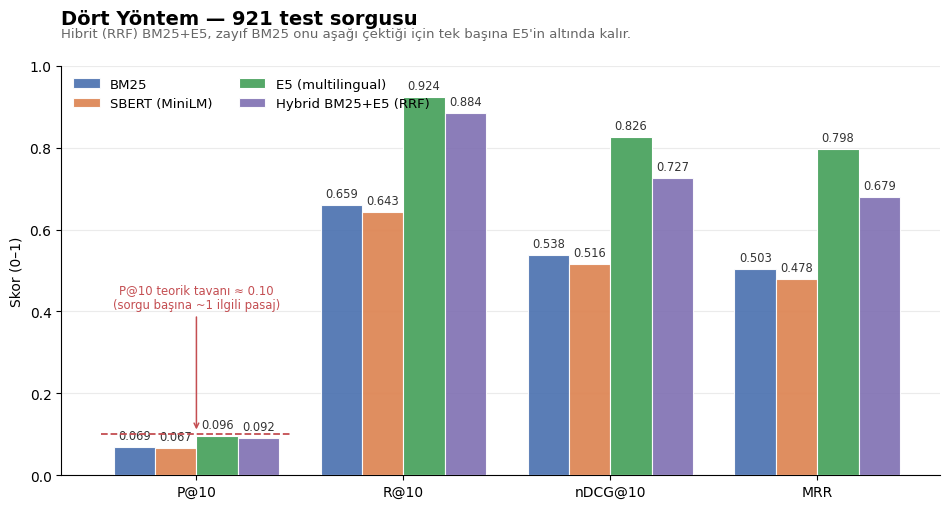

In [21]:
def rrf_fuse(rankings, rrf_k=60, top_k=10):
    """Reciprocal Rank Fusion: birden fazla retrieval sıralamasını birleştirir."""
    scores = defaultdict(float)
    for ranking in rankings:
        for rank, pid in enumerate(ranking, start=1):
            scores[pid] += 1.0 / (rrf_k + rank)
    return [pid for pid, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_k]]

def run_hybrid_rrf(max_pool=50, top_k=10, rrf_k=60):
    out = {}
    for qid, qtext in zip(queries_df[QID_COL], queries_df[QTEXT].astype(str)):
        bm_ids, _ = bm25_search(qtext, top_k=max_pool)
        e5_ids, _ = e5_search(qtext, top_k=max_pool)
        out[qid] = rrf_fuse([bm_ids, e5_ids], rrf_k=rrf_k, top_k=top_k)
    return out

t0 = time.time()
retr_hybrid = run_hybrid_rrf(max_pool=50, top_k=max(K_VALUES), rrf_k=60)
print(f'Hibrit RRF erisim suresi: {time.time()-t0:.1f} sn')

res_hybrid = evaluate_cached(retr_hybrid, 'Hybrid BM25+E5 (RRF)')
comp_hybrid_df = pd.DataFrame([res_bm25, res_sbert, res_e5, res_hybrid])[cols_order]
print('=== Dört Yöntem Karşılaştırması ===')
print(comp_hybrid_df.to_string(index=False))

best_model = comp_hybrid_df.sort_values('MRR', ascending=False).iloc[0]
print(f"\nMRR@10'a göre en iyi yöntem: {best_model['Model']} | MRR@10={best_model['MRR']:.4f}")

# --- Dört yöntem grafiği (hibrit dahil) ---
plot_metric_bars([("BM25", res_bm25), ("SBERT (MiniLM)", res_sbert),
                  ("E5 (multilingual)", res_e5), ("Hybrid BM25+E5 (RRF)", res_hybrid)],
    metrics_plot, "Dört Yöntem — %d test sorgusu" % len(queries_df),
    "Hibrit (RRF) BM25+E5, zayıf BM25 onu aşağı çektiği için tek başına E5'in altında kalır.",
    highlight="E5 (multilingual)")

Hibrit yöntemi (RRF ile BM25 + E5) değerlendirildiğinde aşağıdaki tablo elde edilir:

| Model | P@1 | R@10 | nDCG@10 | MRR |
|---|---|---|---|---|
| BM25 | 0.4235 | 0.6589 | 0.5376 | 0.5030 |
| SBERT (MiniLM) | 0.4017 | 0.6430 | 0.5159 | 0.4785 |
| **E5 (multilingual)** | **0.7253** | **0.9240** | **0.8258** | **0.7976** |
| Hybrid BM25+E5 (RRF) | 0.5809 | 0.8845 | 0.7267 | 0.6792 |

Burada dikkat çeken sonuç, **hibrit yöntemin E5'i geçememesi**, hatta onun altında kalmasıdır (MRR 0.679 < 0.798). Bunun nedeni, Reciprocal Rank Fusion'ın iki sıralamayı eşit ağırlıkla birleştirmesidir; BM25 bu veri setinde E5'ten çok daha zayıf olduğu için (MRR 0.503'e karşı 0.798), füzyon güçlü olan E5'in üst sıralarını zayıf BM25 sonuçlarıyla seyreltiyor ve başarımı aşağı çekiyor. Hibrit ancak iki yöntem benzer güçte ve gerçekten tamamlayıcı olduğunda kazanç sağlar; tek bir yöntem açık ara üstünse onu tek başına kullanmak daha doğrudur.

Bu, "iki yöntemi birleştirmek her zaman daha iyidir" varsayımının yanlış olduğunu gösteren öğretici bir sonuç. Daha iyi bir birleştirme için eşit-ağırlıklı RRF yerine ağırlıklı füzyon ya da E5'in ilk sonuçlarını yeniden sıralayan bir cross-encoder denenebilir.

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Batches:   0%|          | 0/625 [00:00<?, ?it/s]

E5-large kodlama: (40000, 1024) | 161.6 sn
E5-large erişim (921 sorgu): 27.8 sn

=== Dört Yöntem — Tam Karşılaştırma ===
                  Model    P@1    P@5   P@10    R@1    R@5   R@10  nDCG@1  nDCG@5  nDCG@10    MRR
                   BM25 0.4235 0.1249 0.0685 0.4126 0.6019 0.6589  0.4235  0.5186   0.5376 0.5030
         SBERT (MiniLM) 0.4017 0.1197 0.0668 0.3909 0.5762 0.6430  0.4017  0.4941   0.5159 0.4785
      E5 (multilingual) 0.7253 0.1848 0.0959 0.7085 0.8909 0.9240  0.7253  0.8148   0.8258 0.7976
E5-large (multilingual) 0.7796 0.1896 0.0979 0.7633 0.9126 0.9425  0.7796  0.8533   0.8630 0.8390

MRR@10'a göre en iyi: E5-large (multilingual)  |  MRR=0.8390


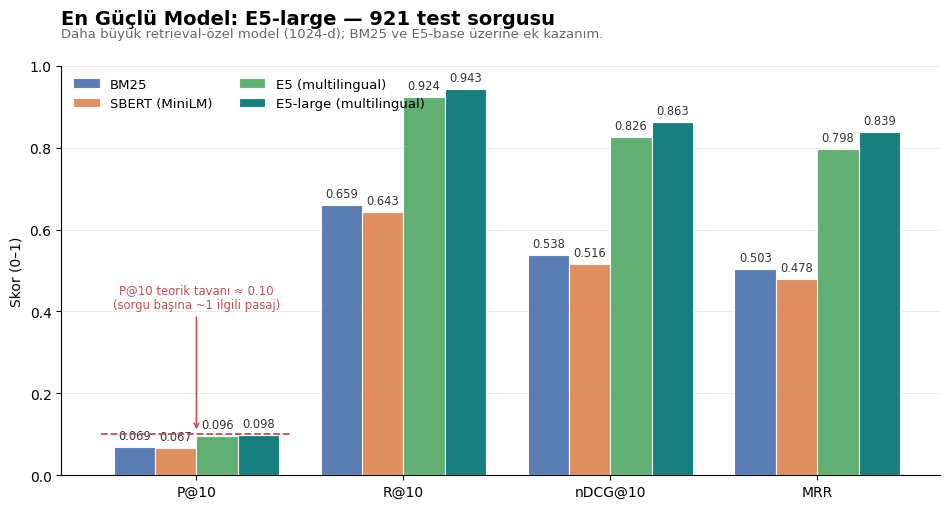


=== Sorgu tipine göre MRR (E5-base vs E5-large) ===
Model                    Kısa (≤5)   Uzun (>5)
E5 (base)                   0.7931      0.8086   (n_kısa=652, n_uzun=269)
E5-large                    0.8375      0.8427   (n_kısa=652, n_uzun=269)


In [22]:
# =========================================================================
# DAHA GÜÇLÜ MODEL: multilingual-e5-large (retrieval'a özel, 1024-d)
# Klasik (BM25) + anlamsal (MiniLM, E5-base, E5-large) karşılaştırması
# =========================================================================
import time, numpy as np, torch
from sentence_transformers import SentenceTransformer
import faiss

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- 1) Modeli yükle ve corpus'u kodla (E5: 'passage: ' / 'query: ' öneki şart) ---
E5L_NAME = 'intfloat/multilingual-e5-large'
e5l = SentenceTransformer(E5L_NAME, device=device)

t0 = time.time()
e5l_corpus_emb = e5l.encode(
    ['passage: ' + t for t in corpus_texts],
    batch_size=64, normalize_embeddings=True,
    convert_to_numpy=True, show_progress_bar=True
).astype('float32')
print(f'E5-large kodlama: {e5l_corpus_emb.shape} | {time.time()-t0:.1f} sn')

# --- 2) FAISS indeksi (normalize edilmiş vektörlerde iç-çarpım = kosinüs) ---
e5l_index = faiss.IndexFlatIP(e5l_corpus_emb.shape[1])
e5l_index.add(e5l_corpus_emb)

def e5l_search(qtext, top_k=10):
    qv = e5l.encode(['query: ' + qtext], normalize_embeddings=True,
                    convert_to_numpy=True).astype('float32')
    D, I = e5l_index.search(qv, top_k)
    return [corpus_ids[i] for i in I[0]], D[0]

# --- 3) Tüm test sorguları için erişim + değerlendirme ---
t0 = time.time()
retr_e5l = {qid: e5l_search(qtext, top_k=max(K_VALUES))[0]
            for qid, qtext in zip(queries_df[QID_COL], queries_df[QTEXT].astype(str))}
print(f'E5-large erişim ({len(retr_e5l)} sorgu): {time.time()-t0:.1f} sn')
res_e5l = evaluate_cached(retr_e5l, 'E5-large (multilingual)')

# --- 4) Karşılaştırma tablosu + grafik (dört yöntem) ---
COL['E5-large (multilingual)'] = '#17807E'          # grafiğe yeni renk ekle
comp_all = pd.DataFrame([res_bm25, res_sbert, res_e5, res_e5l])[cols_order]
print('\n=== Dört Yöntem — Tam Karşılaştırma ===')
print(comp_all.to_string(index=False))

best = comp_all.sort_values('MRR', ascending=False).iloc[0]
print(f"\nMRR@10'a göre en iyi: {best['Model']}  |  MRR={best['MRR']:.4f}")

plot_metric_bars(
    [('BM25', res_bm25), ('SBERT (MiniLM)', res_sbert),
     ('E5 (multilingual)', res_e5), ('E5-large (multilingual)', res_e5l)],
    metrics_plot,
    'En Güçlü Model: E5-large — %d test sorgusu' % len(queries_df),
    "Daha büyük retrieval-özel model (1024-d); BM25 ve E5-base üzerine ek kazanım.",
    highlight='E5-large (multilingual)')

# --- 5) Son madde: sorgu tipine göre hangi model daha başarılı? (E5-base vs E5-large) ---
def mrr_by_len(retr):
    s = l = 0.0; ns = nl = 0
    for qid in queries_df[QID_COL]:
        rr = 0.0
        for rank, pid in enumerate(retr[qid], start=1):
            if pid in gold[qid]:
                rr = 1.0 / rank; break
        if len(str(qid2qtext[qid]).split()) <= 5:
            s += rr; ns += 1
        else:
            l += rr; nl += 1
    return s / max(ns, 1), l / max(nl, 1), ns, nl

# E5-base erişimini (hızlı) yeniden üret, grup MRR'lerini karşılaştır
retr_e5 = {qid: e5_search(qtext, top_k=max(K_VALUES))[0]
           for qid, qtext in zip(queries_df[QID_COL], queries_df[QTEXT].astype(str))}

print('\n=== Sorgu tipine göre MRR (E5-base vs E5-large) ===')
print(f"{'Model':<22}{'Kısa (≤5)':>12}{'Uzun (>5)':>12}")
for name, retr in [('E5 (base)', retr_e5), ('E5-large', retr_e5l)]:
    sm, lm, ns, nl = mrr_by_len(retr)
    print(f'{name:<22}{sm:>12.4f}{lm:>12.4f}   (n_kısa={ns}, n_uzun={nl})')

**En güçlü model — multilingual-E5-large analizi.** Modeli daha da güçlendirmek için E5'in büyük sürümünü (1024 boyutlu `multilingual-e5-large`) aynı koşullarda denedim:

| Model | P@1 | R@10 | nDCG@10 | MRR |
|---|---|---|---|---|
| BM25 | 0.4235 | 0.6589 | 0.5376 | 0.5030 |
| SBERT (MiniLM) | 0.4017 | 0.6430 | 0.5159 | 0.4785 |
| E5 (base) | 0.7253 | 0.9240 | 0.8258 | 0.7976 |
| **E5-large** | **0.7796** | **0.9425** | **0.8630** | **0.8390** |

E5-large, E5-base üzerine net bir kazanım sağladı: MRR 0.798 → **0.839**, Recall@10 0.924 → **0.943**, ilk sıra doğruluğu (P@1) 0.725 → **0.780**. Yani doğru pasajı sorguların yaklaşık %94'ünde ilk 10 sonuca, %78'inde doğrudan ilk sıraya taşıyor. Bu artış, daha büyük ve daha güçlü kodlayıcının asimetrik soru–pasaj eşleştirmesini daha iyi modellemesinden geliyor.

Son maddeyi (hangi sorgu tipinde hangi model daha başarılı) bu kez E5-base ile E5-large arasında incelendi:

| Model | Kısa sorgu (≤5) MRR | Uzun sorgu (>5) MRR |
|---|---|---|
| E5 (base) | 0.7931 | 0.8086 |
| **E5-large** | **0.8375** | **0.8427** |

Önceki bölümde BM25 ile MiniLM birbirini sorgu tipine göre **dönüşümlü** olarak yenerken (BM25 kısa, MiniLM uzun sorguda üstün), burada farklı bir tablo görüyorum: E5-large her iki sorgu tipinde de E5-base'i geçiyor. Yani retrieval'a özel güçlü bir model yalnızca belirli bir sorgu tipinde değil, **her tipte** tutarlı biçimde daha iyi. Bedeli kodlama süresidir (E5-large 161.6 sn; E5-base 52.2 sn); uygulamada bu maliyet–başarı dengesine göre seçim yapılmalıdır.

---
## 10. Sonuç

Bu çalışmada Türkçe `parsak/msmarco-tr` koleksiyonu üzerinde sözlüksel ve anlamsal belge getirme yöntemlerini aynı koşullarda karşılaştırdım. Ulaştığım başlıca sonuçlar şunlardır:

1. **Modelin göreve uygunluğu, veri miktarından daha belirleyicidir.** Genel amaçlı bir cümle benzerliği modeli olan MiniLM, sözlüksel baseline BM25'i geçemezken (MRR 0.479 < 0.503), bilgi erişim görevleri için özel olarak geliştirilen E5-base her iki yöntemi de büyük farkla geçti (MRR 0.798) ve daha büyük E5-large en yüksek başarımı verdi (MRR **0.839**, Recall@10 **0.943**).
2. **Sözlüksel ve anlamsal yöntemler birbirini tamamlar:** BM25 kısa ve özel-isim içeren sorgularda, dense modeller ise uzun ve cümle benzerliği içeren sorgularda üstün. Ancak iki yöntemi eşit ağırlıkla birleştiren basit bir hibrit, zayıf BM25'in güçlü E5'i aşağı çekmesi nedeniyle E5'i geçemedi.
3. **Metrik yorumu kritiktir:** seyrek etiketleme nedeniyle Precision@k düşük *görünür*; başarıyı MRR, Recall@10 ve nDCG üzerinden okumak gerekir.

**İleride yapılabilecekler.** E5-large'ın getirdiği ilk sonuçları bir cross-encoder ile yeniden sıralamak (retrieve & re-rank), BM25 ile dense skorlarını ağırlıklı biçimde birleştirmek, modeli `parsak/msmarco-tr`'nin eğitim üçlüleriyle alana özgü eğitmek (fine-tuning) ve corpus boyutunu kademeli büyüterek ölçek–başarı ilişkisini incelemek doğal devam adımlarıdır.


---
## 11. Kaynakça

1. Robertson, S., & Zaragoza, H. (2009). *The Probabilistic Relevance Framework: BM25 and Beyond.* Foundations and Trends in Information Retrieval, 3(4), 333–389.
2. Reimers, N., & Gurevych, I. (2019). *Sentence-BERT: Sentence Embeddings using Siamese BERT-Networks.* EMNLP-IJCNLP 2019.
3. Karpukhin, V., et al. (2020). *Dense Passage Retrieval for Open-Domain Question Answering.* EMNLP 2020.
4. Wang, L., et al. (2024). *Multilingual E5 Text Embeddings: A Technical Report.* arXiv:2402.05672.
5. Johnson, J., Douze, M., & Jégou, H. (2019). *Billion-scale Similarity Search with GPUs.* IEEE Transactions on Big Data, 7(3), 535–547.
6. Nguyen, T., et al. (2016). *MS MARCO: A Human Generated MAchine Reading COmprehension Dataset.* arXiv:1611.09268.
7. Bonifacio, L., et al. (2021). *mMARCO: A Multilingual Version of the MS MARCO Passage Ranking Dataset.* arXiv:2108.13897.

**Veri seti:** parsak/msmarco-tr — https://huggingface.co/datasets/parsak/msmarco-tr
**Modeller:** sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2; intfloat/multilingual-e5-base
**Kütüphaneler:** Hugging Face Datasets & Transformers, Sentence-Transformers, rank-bm25, FAISS.

---
### Ek — Araç Kullanım Beyanı
Bu projenin kodlama ve raporlama aşamalarında bir yapay zekâ asistanından (büyük dil modeli) yöntem seçimi, kod iskeleti ve metin düzenleme konusunda destek alınmıştır. Tüm deneyler öğrenci tarafından çalıştırılmış, sonuçlar doğrulanmış ve yorumlar gözden geçirilmiştir.

*— Ahmetcan PEKTAŞ, BM5204 Doğal Dil İşleme — Final Projesi*
